# SARIMA and SARIMAX

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

from src.models.sarima import *

In [2]:
inf_data = pd.read_csv('..//data//processed//combined_macro_data.csv').set_index(['Date'])
inf_data.index = pd.to_datetime(inf_data.index)
inf_rate = inf_data['InflationRate'].dropna()

## I. SARIMA

In [3]:
sarimax_test(ts_data=inf_rate, test_size = 24, n_splits=5)

Folds: 5
Test Size: 24
Fold 1, Test RMSE: 0.49, Seasonal Naive RMSE: 2.51, STD: 0.90
Fold 2, Test RMSE: 1.78, Seasonal Naive RMSE: 2.26, STD: 1.95
Fold 3, Test RMSE: 1.54, Seasonal Naive RMSE: 2.08, STD: 0.85
Fold 4, Test RMSE: 1.20, Seasonal Naive RMSE: 2.69, STD: 1.72
Fold 5, Test RMSE: 1.85, Seasonal Naive RMSE: 2.58, STD: 1.58
RMSE Mean: 1.37   Seasonal Naive Mean: 2.42
RMSE STD: 0.50   Seasonal Naive STD: 0.22


In [4]:
model, forecast, conf = sarimax_forecast(ts_data=inf_rate.dropna(), n_forecast=6)
print(model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  821
Model:             SARIMAX(1, 1, 2)x(0, 0, [1], 12)   Log Likelihood               -1209.392
Date:                              Fri, 10 Jul 2026   AIC                           2428.784
Time:                                      21:13:59   BIC                           2452.330
Sample:                                  01-01-1958   HQIC                          2437.819
                                       - 05-01-2026                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8826      0.022     40.765      0.000       0.840       0.925
ma.L1         -0.53

In [5]:
forecast

2026-06-01    7.036636
2026-07-01    7.390334
2026-08-01    7.378207
2026-09-01    7.795006
2026-10-01    8.106122
2026-11-01    8.447115
Freq: MS, dtype: float64

In [6]:
conf

array([[ 4.98307489,  9.0901977 ],
       [ 3.94825856, 10.83240963],
       [ 2.71934304, 12.03707069],
       [ 1.98436644, 13.6056464 ],
       [ 1.18158774, 15.03065527],
       [ 0.43739453, 16.45683619]])

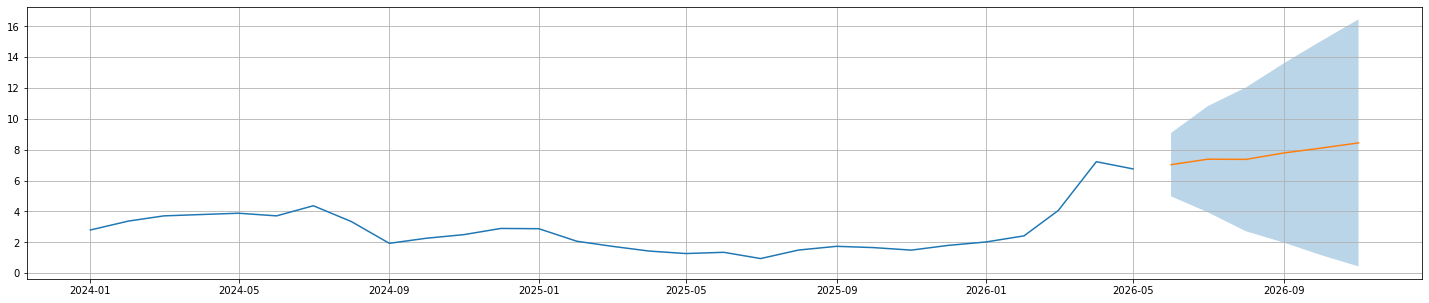

In [7]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(forecast)
plt.fill_between(forecast.index, conf[:, 0], conf[:,1], alpha = 0.3)
plt.grid(True)
plt.show()

## 2. SARIMA (Reduced)

In [8]:
full_data = inf_data.dropna()
reduced_inf = full_data['InflationRate']
targ_col = ['InflationRate']
exog_cols = [col for col in full_data.columns if col not in targ_col]

In [9]:
sarimax_test(reduced_inf, n_splits=5, test_size = 24)

Folds: 5
Test Size: 24
Fold 1, Test RMSE: 0.60, Seasonal Naive RMSE: 2.51, STD: 0.90
Fold 2, Test RMSE: 1.50, Seasonal Naive RMSE: 2.26, STD: 1.95
Fold 3, Test RMSE: 1.18, Seasonal Naive RMSE: 2.08, STD: 0.85
Fold 4, Test RMSE: 1.63, Seasonal Naive RMSE: 2.69, STD: 1.72
Fold 5, Test RMSE: 1.93, Seasonal Naive RMSE: 2.58, STD: 1.58
RMSE Mean: 1.37   Seasonal Naive Mean: 2.42
RMSE STD: 0.45   Seasonal Naive STD: 0.22


In [10]:
model, forecast, conf = sarimax_forecast(ts_data=reduced_inf, n_forecast=6)
print(model.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                  257
Model:             SARIMAX(0, 1, 1)x(2, 0, [], 12)   Log Likelihood                -139.621
Date:                             Fri, 10 Jul 2026   AIC                            287.243
Time:                                     21:14:57   BIC                            301.424
Sample:                                 01-01-2005   HQIC                           292.946
                                      - 05-01-2026                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.4899      0.038     13.045      0.000       0.416       0.564
ar.S.L12      -0.6005      

In [11]:
forecast

2026-06-01    5.949502
2026-07-01    5.994330
2026-08-01    5.972430
2026-09-01    6.253181
2026-10-01    6.203763
2026-11-01    6.230273
Freq: MS, dtype: float64

In [12]:
conf

array([[5.13992293, 6.75908197],
       [4.54163466, 7.44702532],
       [4.08424913, 7.86061162],
       [4.01261596, 8.49374668],
       [3.65915329, 8.74837242],
       [3.41425719, 9.04628793]])

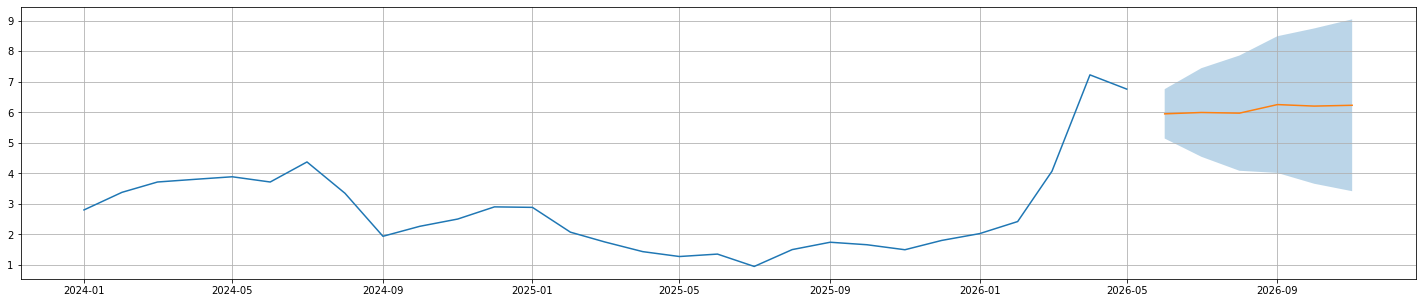

In [13]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(forecast)
plt.fill_between(forecast.index, conf[:, 0], conf[:,1], alpha = 0.3)
plt.grid(True)
plt.show()

## III. SARIMAX

In [14]:
sarimax_test(full_data, test_size = 24, n_splits=5, target_col=targ_col[0], exog_cols=exog_cols)

Folds: 5
Test Size: 24
Fold 1, Test RMSE: 1.43, Seasonal Naive RMSE: 2.51, STD: 0.90
Fold 2, Test RMSE: 2.23, Seasonal Naive RMSE: 2.26, STD: 1.95
Fold 3, Test RMSE: 2.47, Seasonal Naive RMSE: 2.08, STD: 0.85
Fold 4, Test RMSE: 1.59, Seasonal Naive RMSE: 2.69, STD: 1.72
Fold 5, Test RMSE: 2.02, Seasonal Naive RMSE: 2.58, STD: 1.58
RMSE Mean: 1.95   Seasonal Naive Mean: 2.42
RMSE STD: 0.39   Seasonal Naive STD: 0.22


In [15]:
model, forecast, conf = sarimax_forecast(ts_data=inf_data.dropna(), n_forecast=6, target_col=targ_col, exog_cols=exog_cols)
print(model.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                    y   No. Observations:                  257
Model:             SARIMAX(2, 1, 2)x(1, 0, [1], 12)   Log Likelihood                -119.880
Date:                              Fri, 10 Jul 2026   AIC                            261.760
Time:                                      21:17:28   BIC                            300.757
Sample:                                  01-01-2005   HQIC                           277.445
                                       - 05-01-2026                                         
Covariance Type:                                opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept           -0.0036      0.008     -0.453      0.650      -0.019       0.012
U

In [16]:
forecast

2026-06-01    6.587447
2026-07-01    6.812784
2026-08-01    6.458149
2026-09-01    6.685298
2026-10-01    6.797333
2026-11-01    6.979663
Freq: MS, dtype: float64

In [17]:
conf

array([[5.85600263, 7.31889128],
       [5.51534261, 8.11022535],
       [4.71899768, 8.19729972],
       [4.53848042, 8.83211587],
       [4.29275335, 9.30191212],
       [4.14847522, 9.81084993]])

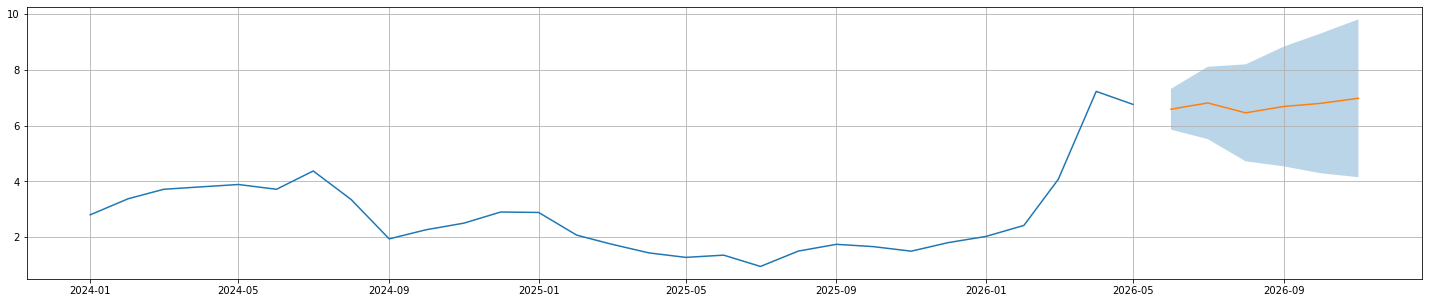

In [18]:
plt.figure(figsize = (25, 5))
plt.plot(inf_rate['2024':])
plt.plot(forecast)
plt.fill_between(forecast.index, conf[:, 0], conf[:,1], alpha = 0.3)
plt.grid(True)
plt.show()